# Comprehensive Exploratory Data Analysis: India Soil Health

**Objective:**
This notebook performs Exploratory Data Analysis (EDA) on the consolidated macro and micronutrient soil data extracted from the DAC Soil Health dashboard. 

**Analytical Goals:**
1. **Data Validation:** Ensure the integrity of the consolidated dataset.
2. **Macronutrient Profiling:** Analyze the distribution of N, P, K across tested regions.
3. **Micronutrient Vulnerabilities:** Identify geographic hotspots for critical deficiencies (Zinc, Iron, Sulphur).
4. **Soil Chemistry:** Evaluate the relationship between soil pH and Electrical Conductivity (Salinity).

In [2]:
# --- Setup and Configuration ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

# Suppress harmless warnings for cleaner output
warnings.filterwarnings('ignore')

# Set a professional, publication-ready visual theme
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.titlesize': 16,
    'axes.labelsize': 12,
    'font.weight': 'bold',
    'axes.titleweight': 'bold'
})

# Define output directory for exported assets
OUTPUT_DIR = '../output_charts'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Environment configured successfully.")

Environment configured successfully.


## 1. Data Ingestion & Validation
Before deriving insights, we must confirm the shape, completeness, and data types of our consolidated pipeline output.

In [3]:
# Load the dataset
data_path = '../data/processed/consolidated_soil_data.csv'
df = pd.read_csv(data_path)

# Display dataset metadata
print(f"Dataset Shape: {df.shape[0]:,} rows | {df.shape[1]} columns")
print("-" * 50)

# Check for any lingering nulls (should be 0 if the ETL pipeline succeeded)
missing_vals = df.isnull().sum().sum()
print(f"Total Missing Values: {missing_vals}")

# Preview the data structure
display(df.head(3))

Dataset Shape: 6,214 rows | 34 columns
--------------------------------------------------
Total Missing Values: 0


,cycle,state_name,district_name,block_name,village_name,N_High,N_Low,N_Medium,P_High,P_Low,...,Fe_Sufficient,Fe_Deficient,Zn_Sufficient,Zn_Deficient,Cu_Sufficient,Cu_Deficient,B_Sufficient,B_Deficient,Mn_Sufficient,Mn_Deficient
0,2024-25,Andhra Pradesh,Alluri Sitharama Raju,Addateegala,Vetamamidi,0,1,1,2,0,...,2,0,2,0,1,1,2,0,2,0
1,2024-25,Andhra Pradesh,Alluri Sitharama Raju,Addateegala,Kimmuru,0,2,7,4,3,...,9,0,9,0,9,0,0,9,9,0
2,2024-25,Andhra Pradesh,Alluri Sitharama Raju,Addateegala,Kinaparti,1,1,4,2,4,...,6,0,6,0,6,0,0,6,6,0


## 2. Feature Engineering: Normalizing Test Metrics
Raw test counts (e.g., 50 tests showing 'Low' Nitrogen) are not comparable across villages of different sizes. To compare regions equitably, we must engineer normalized features representing the **percentage** of tests falling into each category.

In [4]:
# 1. Total Macronutrient Tests
df['Total_N_Tests'] = df['N_High'] + df['N_Medium'] + df['N_Low']
df['Total_P_Tests'] = df['P_High'] + df['P_Medium'] + df['P_Low']
df['Total_K_Tests'] = df['K_High'] + df['K_Medium'] + df['K_Low']

# Calculate Deficiency Percentages for Macronutrients (Low %)
df['N_Deficiency_Pct'] = np.where(df['Total_N_Tests'] > 0, (df['N_Low'] / df['Total_N_Tests']) * 100, 0)
df['P_Deficiency_Pct'] = np.where(df['Total_P_Tests'] > 0, (df['P_Low'] / df['Total_P_Tests']) * 100, 0)
df['K_Deficiency_Pct'] = np.where(df['Total_K_Tests'] > 0, (df['K_Low'] / df['Total_K_Tests']) * 100, 0)

# 2. Total Micronutrient Tests & Deficiency Percentages
micro_elements = ['S', 'Fe', 'Zn', 'Cu', 'B', 'Mn']

for el in micro_elements:
    total_col = f'Total_{el}_Tests'
    df[total_col] = df[f'{el}_Sufficient'] + df[f'{el}_Deficient']
    
    # Avoid division by zero using np.where
    df[f'{el}_Deficiency_Pct'] = np.where(
        df[total_col] > 0, 
        (df[f'{el}_Deficient'] / df[total_col]) * 100, 
        0
    )

# 3. Organic Carbon (OC) Deficiency
df['Total_OC_Tests'] = df['OC_High'] + df['OC_Medium'] + df['OC_Low']
df['OC_Deficiency_Pct'] = np.where(df['Total_OC_Tests'] > 0, (df['OC_Low'] / df['Total_OC_Tests']) * 100, 0)

print("Engineered normalized percentage features successfully.")

Engineered normalized percentage features successfully.


## 3. Insight Generation: The NPK Profile
Nitrogen (N), Phosphorus (P), and Potassium (K) are the primary drivers of crop yield. We will aggregate the national test results to visualize the overarching health of these critical macronutrients.

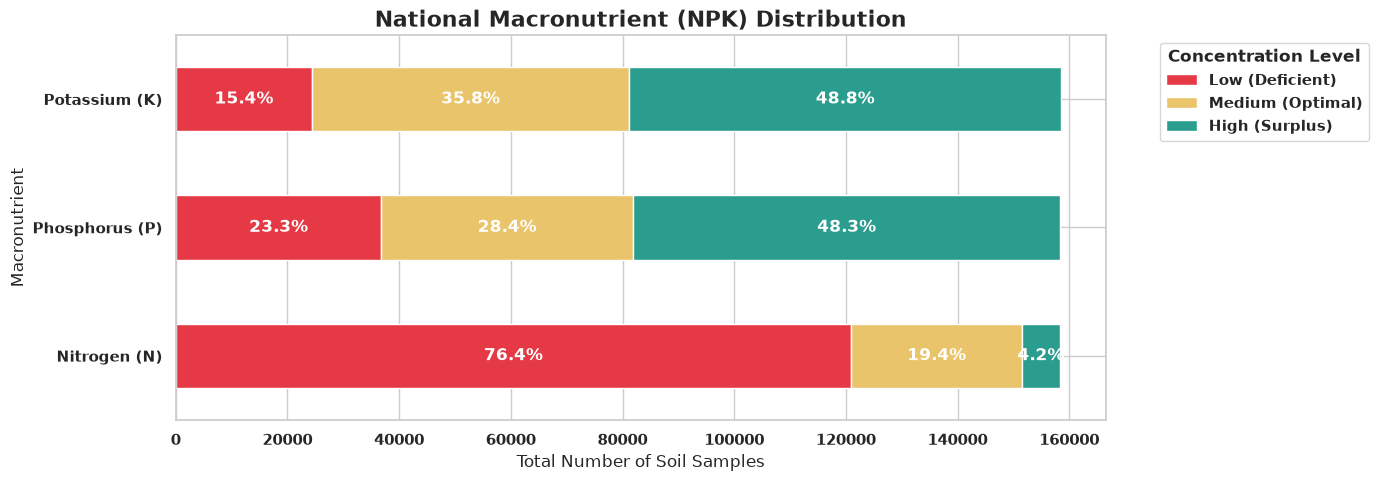

In [5]:
# Aggregate sum of all tests across the dataset
npk_totals = {
    'Nitrogen (N)': [df['N_Low'].sum(), df['N_Medium'].sum(), df['N_High'].sum()],
    'Phosphorus (P)': [df['P_Low'].sum(), df['P_Medium'].sum(), df['P_High'].sum()],
    'Potassium (K)': [df['K_Low'].sum(), df['K_Medium'].sum(), df['K_High'].sum()]
}

npk_df = pd.DataFrame(npk_totals, index=['Low (Deficient)', 'Medium (Optimal)', 'High (Surplus)']).T

# Plot Stacked Bar Chart
ax = npk_df.plot(kind='barh', stacked=True, color=['#e63946', '#e9c46a', '#2a9d8f'], figsize=(12, 5))

plt.title('National Macronutrient (NPK) Distribution')
plt.xlabel('Total Number of Soil Samples')
plt.ylabel('Macronutrient')
plt.legend(title='Concentration Level', bbox_to_anchor=(1.05, 1), loc='upper left')

# Annotate bars with percentages
for c in ax.containers:
    # Filter out 0 values so labels don't overlap on empty bars
    labels = [f'{w/npk_df.sum(axis=1).iloc[i]*100:.1f}%' if (w := v.get_width()) > 0 else '' for i, v in enumerate(c)]
    ax.bar_label(c, labels=labels, label_type='center', color='white', fontweight='bold')

plt.savefig(f'{OUTPUT_DIR}/npk_distribution.png', bbox_inches='tight')
plt.show()

> **Strategic Takeaway 1:** Observe the Nitrogen (N) distribution. If the red (Low) segment dominates, it indicates a systemic nitrogen deficiency across the sampled regions, necessitating heavy reliance on Urea fertilizers. Conversely, Potassium (K) often shows higher natural sufficiency.

## 4. Regional Heatmap: Micronutrient Vulnerabilities
Micronutrient deficiencies (like Zinc and Sulphur) silently stunt crop growth. Using a heatmap, we can identify specific states that require targeted micronutrient interventions.

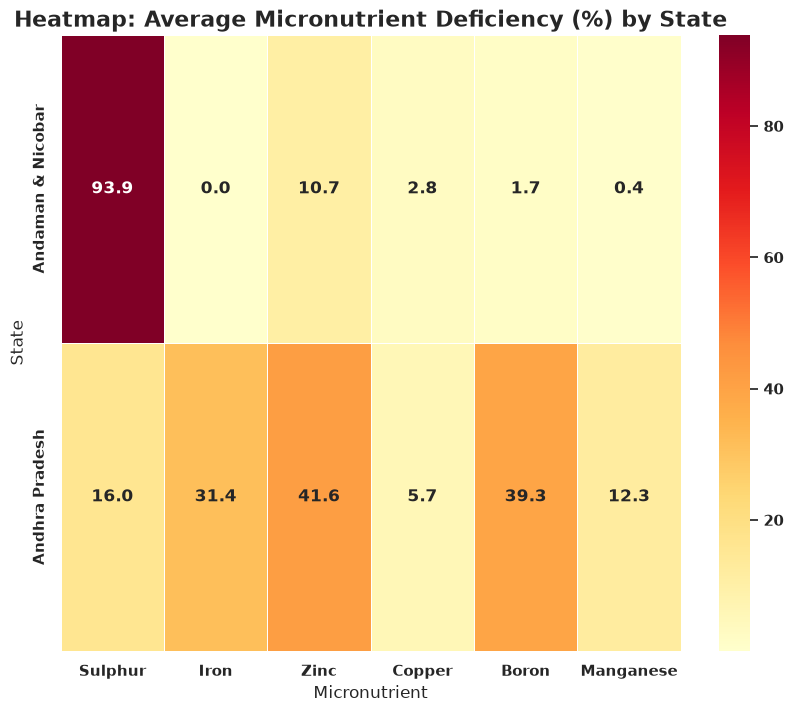

In [8]:
# Filter out rows with 0 tests to avoid skewing the mean
micro_pct_cols = [f'{el}_Deficiency_Pct' for el in micro_elements]
valid_micro_df = df[df[micro_pct_cols].sum(axis=1) > 0]

# Group by State and calculate the mean deficiency percentage for each element
state_micro_heatmap = valid_micro_df.groupby('state_name')[micro_pct_cols].mean()

# Rename columns for cleaner visualization
state_micro_heatmap.columns = ['Sulphur', 'Iron', 'Zinc', 'Copper', 'Boron', 'Manganese']

plt.figure(figsize=(10, 8))
sns.heatmap(state_micro_heatmap, annot=True, fmt=".1f", cmap="YlOrRd", linewidths=.5)

plt.title('Heatmap: Average Micronutrient Deficiency (%) by State')
plt.ylabel('State')
plt.xlabel('Micronutrient')

plt.savefig(f'{OUTPUT_DIR}/micronutrient_heatmap.png', bbox_inches='tight')
plt.show()

> **Strategic Takeaway 2:** The heatmap acts as a triage tool for agricultural policy. Dark red cells pinpoint acute regional vulnerabilities (e.g., severe Zinc deficiency in a specific state) where government subsidies for fortified fertilizers would yield the highest ROI.

## 5. Soil Chemistry: Organic Carbon vs. pH Levels
Organic Carbon (OC) is the lifeblood of soil, retaining moisture and harboring beneficial microbes. Does soil pH (acidity/alkalinity) correlate with the ability to maintain healthy Organic Carbon levels?

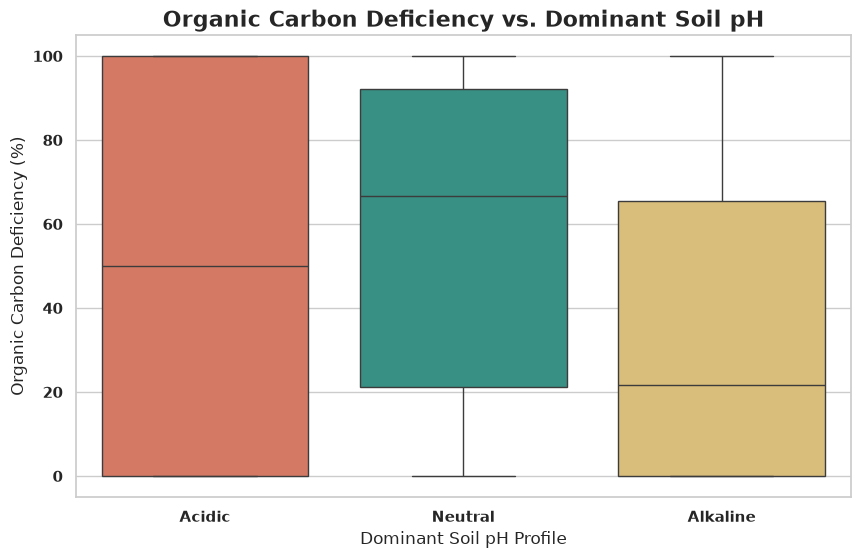

In [7]:
# Determine the dominant pH profile for each village
# (Whichever category has the max tests is designated as the dominant pH for that row)
df['Dominant_pH'] = df[['PH_Acidic', 'PH_Neutral', 'PH_Alkaline']].idxmax(axis=1)
df['Dominant_pH'] = df['Dominant_pH'].map({
    'PH_Acidic': 'Acidic', 
    'PH_Neutral': 'Neutral', 
    'PH_Alkaline': 'Alkaline'
})

# Filter out rows where no OC tests were conducted
oc_valid = df[df['Total_OC_Tests'] > 0]

plt.figure(figsize=(10, 6))
sns.boxplot(x='Dominant_pH', y='OC_Deficiency_Pct', data=oc_valid, 
            palette={'Acidic': '#e76f51', 'Neutral': '#2a9d8f', 'Alkaline': '#e9c46a'},
            order=['Acidic', 'Neutral', 'Alkaline'])

plt.title('Organic Carbon Deficiency vs. Dominant Soil pH')
plt.ylabel('Organic Carbon Deficiency (%)')
plt.xlabel('Dominant Soil pH Profile')

plt.savefig(f'{OUTPUT_DIR}/oc_vs_ph.png', bbox_inches='tight')
plt.show()

> **Strategic Takeaway 3:** Extreme pH levels (highly acidic or highly alkaline) often create harsh environments that degrade organic matter rapidly. If the boxplots show higher median OC deficiency in Alkaline or Acidic soils compared to Neutral soils, it proves that chemical soil correction (like applying lime or gypsum) is a prerequisite to improving organic carbon retention.

## 6. Nutrient Co-Deficiency Correlation
Do certain soil deficiencies cluster together? By running a Pearson correlation matrix on our deficiency percentages, we can determine if soils lacking in one nutrient are statistically likely to lack another. This informs whether combined fertilizer mixes (e.g., NPK + Zinc) are more efficient than single-element applications.

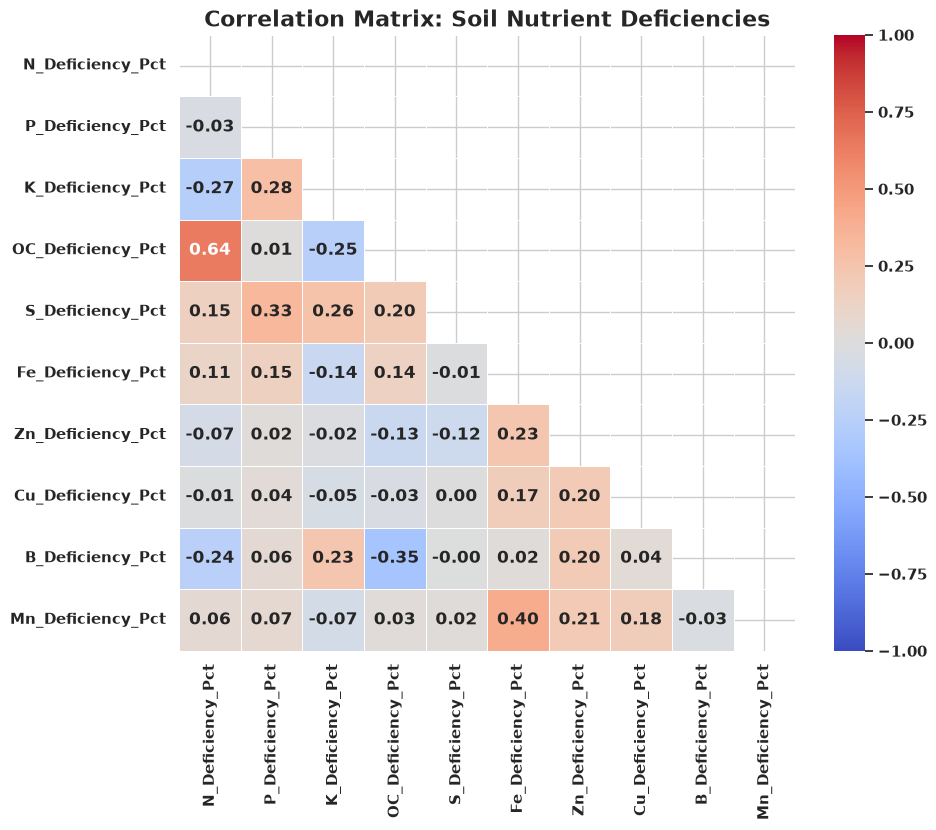

In [9]:
# Select only the percentage columns for correlation
pct_cols = ['N_Deficiency_Pct', 'P_Deficiency_Pct', 'K_Deficiency_Pct', 
            'OC_Deficiency_Pct', 'S_Deficiency_Pct', 'Fe_Deficiency_Pct', 
            'Zn_Deficiency_Pct', 'Cu_Deficiency_Pct', 'B_Deficiency_Pct', 'Mn_Deficiency_Pct']

# Filter out rows where we don't have sufficient data to correlate
corr_df = df[pct_cols].dropna()

# Compute the correlation matrix
corr_matrix = corr_df.corr()

# Mask the upper triangle for a cleaner look
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", 
            vmin=-1, vmax=1, center=0, square=True, linewidths=.5)

plt.title('Correlation Matrix: Soil Nutrient Deficiencies')
plt.savefig(f'{OUTPUT_DIR}/deficiency_correlation.png', bbox_inches='tight')
plt.show()

## 7. The Salinity Crisis (Electrical Conductivity)
High soil salinity (measured via Electrical Conductivity) prevents plant roots from absorbing water, acting as a chemical drought. We will identify the top 10 districts with the highest proportion of saline soil samples.

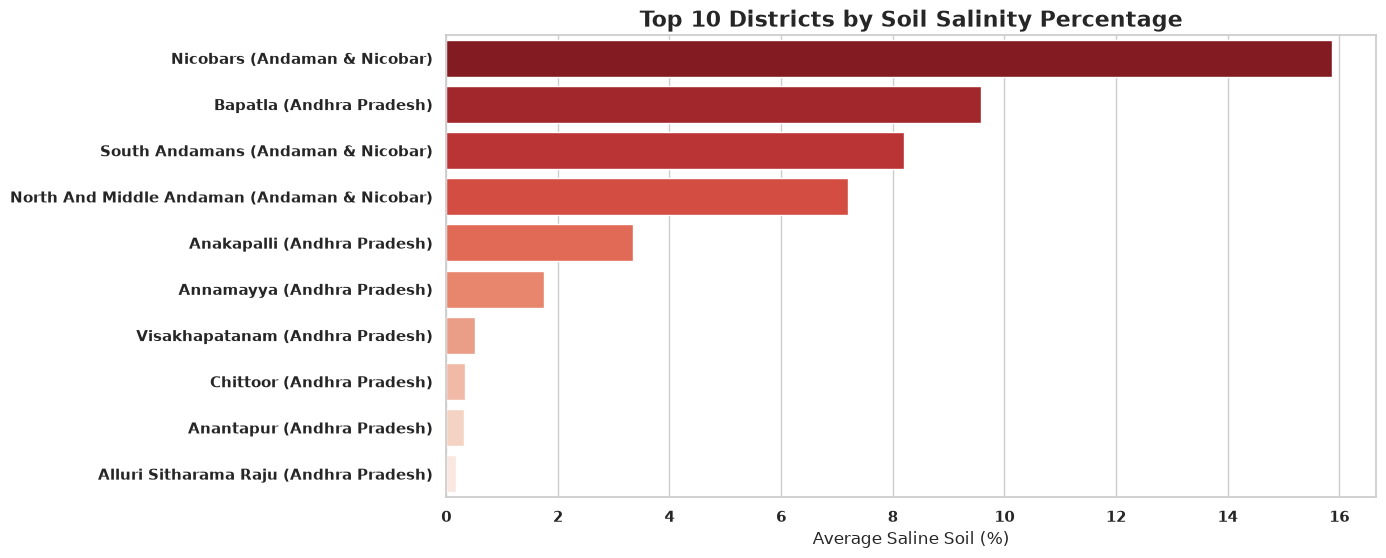

In [12]:
# Calculate Salinity Percentage per row
df['Total_EC_Tests'] = df['EC_Saline'] + df['EC_NonSaline']
df['Saline_Pct'] = np.where(df['Total_EC_Tests'] > 0, (df['EC_Saline'] / df['Total_EC_Tests']) * 100, 0)

# Group by District and get the average Salinity percentage
district_salinity = df[df['Total_EC_Tests'] > 50].groupby(['state_name', 'district_name'])['Saline_Pct'].mean().reset_index()

# Get Top 10 worst affected districts
top_saline_districts = district_salinity.sort_values(by='Saline_Pct', ascending=False).head(10)
top_saline_districts['Location'] = top_saline_districts['district_name'] + " (" + top_saline_districts['state_name'] + ")"

plt.figure(figsize=(12, 6))
sns.barplot(x='Saline_Pct', y='Location', data=top_saline_districts, palette='Reds_r')

plt.title('Top 10 Districts by Soil Salinity Percentage')
plt.xlabel('Average Saline Soil (%)')
plt.ylabel('')

plt.savefig(f'{OUTPUT_DIR}/top_saline_districts.png', bbox_inches='tight')
plt.show()

## 8. Executive Summary & Strategic Insights

Based on the consolidated soil health dataset across the sampled regions, the exploratory data analysis reveals critical vulnerabilities in both macronutrient retention and soil chemistry. 

### Key Findings

**1. The Nitrogen and Organic Carbon Crisis (National Level)**
The data reveals a systemic degradation of baseline soil health. A staggering **67.50% of tested soils are deficient in Nitrogen (N)**, paired closely with a **56.88% deficiency in Organic Carbon (OC)**. Because Organic Carbon is essential for moisture retention and nutrient binding, applying standard NPK fertilizers without first addressing the OC deficit will result in severe nutrient leaching and low ROI for farmers.

**2. The "Silent" Micronutrient Gap**
While Phosphorus and Potassium deficiencies sit at a manageable ~21%, micronutrients present a hidden threat to crop yields. **Zinc (38.61%) and Boron (36.14%) are the most broadly deficient trace elements**, followed by Iron (28.85%). Agricultural initiatives must pivot from generic NPK distributions toward Zinc and Boron-fortified fertilizer blends to unlock yield potential.

**3. Regional Crisis: The Andaman & Nicobar Anomaly**
The territory of Andaman & Nicobar requires immediate soil remediation intervention. It registers catastrophic deficiency levels across every major metric:
* **Macronutrients:** 83.68% N-deficient, 90.04% P-deficient, and 88.74% K-deficient.
* **Organic Carbon:** 90.82% deficient.
* **Salinity:** At 13.47% saline soil, it is over four times the national average (3.35%) and drastically higher than mainland states like Andhra Pradesh (2.90%). 
* *Geological Context:* This profile strongly indicates severe coastal leaching, where heavy rainfall and seawater intrusion strip the soil of organic matter and essential minerals while leaving salt behind.

### Actionable Recommendations
1. **Prioritize OC Remediation:** Subsidize green manure, vermicompost, and crop rotation programs, particularly in regions where OC deficiency exceeds 50%.
2. **Zinc-Fortified Formulations:** Standardize the inclusion of Zinc in state-sponsored fertilizer distributions.
3. **Coastal Soil Rehabilitation:** Launch a specialized salinity-reduction and nutrient-fixing campaign specifically for Andaman & Nicobar, utilizing gypsum treatments and salt-tolerant crop varieties.